# 04 수요패턴 분석 (개요)

매장 **type**별 수요 변동성을 간략히 살펴봅니다.

> **상세 분석**(System/SKU-Level 기초통계, SBC·ML 클러스터별 변동성, **RIDR 지수**, 수요 밴드 시각화)은  
> **`11_제품_수요패턴_RIDR_분석.ipynb`** 에서 논문 3장 스타일로 수행합니다.


In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'code' else NOTEBOOK_DIR
sys.path.insert(0, str(REPO_ROOT / 'code'))
from utils.paths import DATA_PROCESSED
from utils.stats_summary import system_level_weekly_stats, sku_level_weekly_stats
from utils.sbc import compute_sbc_table

dfw = pd.read_parquet(DATA_PROCESSED / 'df_weekly.parquet')
types = sorted(dfw['type'].unique())
print('type 개수:', len(types), types)



type 개수: 5 ['A', 'B', 'C', 'D', 'E']


In [2]:
# type별 System-Level / SKU-Level 기초통계 (논문 Table 3.2 스타일)
system_rows, sku_rows, sku_detail_all = [], [], []
for t in types:
    sys_df = system_level_weekly_stats(dfw, t)
    sku_sum, sku_detail = sku_level_weekly_stats(dfw, t)
    system_rows.append(sys_df)
    sku_rows.append(sku_sum)
    sku_detail_all.append(sku_detail)

system_stats = pd.concat(system_rows, ignore_index=True)
sku_stats = pd.concat(sku_rows, ignore_index=True)
sku_detail = pd.concat(sku_detail_all, ignore_index=True)

print('=== System-Level (type별 주간 총판매) ===')
print(system_stats.round(3))
print('\n=== SKU-Level 요약 (type별 family 시계열 평균 통계) ===')
print(sku_stats.round(3))



=== System-Level (type별 주간 총판매) ===
  type   level  n_weeks         mean       median         std      variance  \
0    A  system      242  1458858.850  1566611.124  432935.975  1.874336e+11   
1    B  system      242   600250.558   607672.684  204724.240  4.191201e+10   
2    C  system      242   679482.407   719666.369  175910.559  3.094452e+10   
3    D  system      242  1450757.425  1594141.125  442576.855  1.958743e+11   
4    E  system      242   247200.148   250152.746  105991.828  1.123427e+10   

      cv  skewness  kurtosis         min          max  
0  0.297    -0.094    -1.106  454496.279  2537359.539  
1  0.341     0.201    -0.955  238151.426  1223427.936  
2  0.259    -0.120    -1.087  268354.749  1121222.554  
3  0.305    -0.220    -1.370  447442.409  2356329.393  
4  0.429    -0.049    -1.120   51409.921   526891.967  

=== SKU-Level 요약 (type별 family 시계열 평균 통계) ===
  type level  n_series  mean_of_mean  mean_of_std  mean_of_cv  median_of_mean
0    A   sku        33     4

In [3]:
# type별 ADI/CV2 분포 (주간 sales 기준, type×family)
sbc_preview = compute_sbc_table(dfw, ['type','family'], qty_col='sales')
print(sbc_preview.groupby(['type','SBC_CLUSTER_LABEL']).size().unstack(fill_value=0))
sbc_preview.head(10)



SBC_CLUSTER_LABEL  Erratic  Intermittent  Lumpy  Smooth
type                                                   
A                        3             8      3      19
B                        2             9      3      19
C                        1            10      3      19
D                        3             9      2      19
E                        2             9      3      19


,type,family,ADI,CV2,SBC_CLUSTER,SBC_CLUSTER_LABEL,n_periods,n_positive
0,A,AUTOMOTIVE,1.000000,0.026484,1,Smooth,242,242
1,A,BABY CARE,NaN,NaN,4,Lumpy,242,0
2,A,BEAUTY,1.000000,0.142160,1,Smooth,242,242
3,A,BEVERAGES,1.000000,0.160200,1,Smooth,242,242
4,A,BOOKS,5.627907,1.108685,4,Lumpy,242,43
5,A,BREAD/BAKERY,1.000000,0.045761,1,Smooth,242,242
6,A,CELEBRATION,1.613333,0.057990,2,Intermittent,242,150
7,A,CLEANING,1.000000,0.023205,1,Smooth,242,242
8,A,DAIRY,1.000000,0.064037,1,Smooth,242,242
9,A,DELI,1.000000,0.020880,1,Smooth,242,242


type별 평균 CV (낮을수록 안정):
type
D    0.618986
B    0.622215
A    0.647985
C    0.717811
E    0.867512
Name: cv, dtype: float64


C:\Users\kjh\AppData\Local\Temp\ipykernel_32680\2777427381.py:7: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kjh\AppData\Local\Temp\ipykernel_32680\2777427381.py:7: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kjh\AppData\Local\Temp\ipykernel_32680\2777427381.py:7: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kjh\AppData\Local\Programs\Python\Python310\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\kjh\AppData\Local\Programs\Python\Python310\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\kjh\App

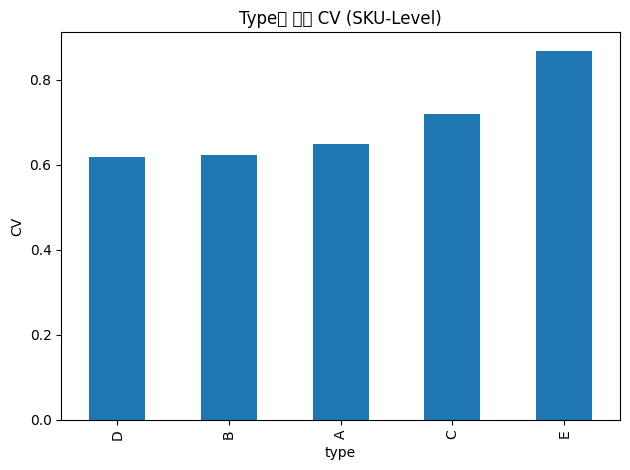

In [4]:
# type별 변동성(CV) 비교 → 이후 SBC vs ML 선택 근거
vol = sku_detail.groupby('type')['cv'].mean().sort_values()
print('type별 평균 CV (낮을수록 안정):')
print(vol)
vol.plot(kind='bar', title='Type별 평균 CV (SKU-Level)')
plt.ylabel('CV')
plt.tight_layout()
plt.show()



In [5]:
# 저장
out_dir = DATA_PROCESSED
system_stats.to_csv(out_dir / 'type_system_level_stats.csv', index=False)
sku_stats.to_csv(out_dir / 'type_sku_level_stats.csv', index=False)
sku_detail.to_csv(out_dir / 'type_family_series_stats.csv', index=False)
print('저장 완료')



저장 완료


## 분석 요약 (개요)

### System-Level (type별 주간 총판매)
| type | 주간 평균 판매 | CV | 왜도 |
|------|---------------|-----|------|
| A | 1,458,859 | 0.30 | -0.09 |
| D | 1,450,757 | 0.31 | -0.22 |
| C | 679,482 | **0.26** | -0.12 |
| B | 600,251 | 0.34 | 0.20 |
| E | 247,200 | **0.43** | -0.05 |

- **type A·D** 규모 최대, **type E** 최소 → 소규모 type(E)일수록 상대 변동성(CV) 큼
- 왜도 대부분 음수 → 극단적 저수요 주가 적은 분포

### SKU-Level (family 시계열 평균 CV)
- **D(0.619) < B(0.622) < A(0.648) < C(0.718) < E(0.868)**
- type D가 family 단위에서 **가장 안정적**, type E가 **가장 변동적**

### SBC 패턴 미리보기 (type×family, 165 시계열)
- 5개 type 모두 **Smooth 19개** 동일 (family 구성 동일)
- **Intermittent**: C type 10개로 최다 / **Lumpy**: D type 2개로 최소

> 상세 분석(RIDR, 클러스터별 밴드)은 **`11_제품_수요패턴_RIDR_분석.ipynb`** 참조